# RLI Assignment 22.00: Mountain Car

## Setup & Dependencies


In [ ]:
# Uncomment to install dependencies (all should be present in the project venv)
# !pip install gymnasium stable-baselines3 torch matplotlib numpy pandas seaborn tensorboard

# Library versions used:
# gymnasium==1.2.3, stable-baselines3==2.8.0, torch==2.10.0, numpy==2.2.6


In [1]:
import sys
sys.path.insert(0, '.')

import mclib as mc

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import seaborn as sns
import time, random, warnings
warnings.filterwarnings('ignore')

import gymnasium as gym
import torch

from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 4)

print("Setup complete.")


Setup complete.


## 1. Environment Analysis

### 1.1 The Mountain Car Problem

In [ ]:
# Explore both environment versions
env_disc = gym.make('MountainCar-v0')
env_cont = gym.make('MountainCarContinuous-v0')

print("DISCRETE: MountainCar-v0")
print(f"Action space: {env_disc.action_space}")
print(f"Observation space: {env_disc.observation_space}")
print(f"Obs low: {env_disc.observation_space.low}")
print(f"Obs high: {env_disc.observation_space.high}")

print("\nCONTINUOUS: MountainCarContinuous-v0")
print(f"Action space: {env_cont.action_space}")
print(f"Observation space: {env_cont.observation_space}")

env_disc.close()
env_cont.close()


In [ ]:
# Visualize the landscape and phase portrait concept
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Mountain Car landscape
x = np.linspace(-1.2, 0.6, 400)
y = np.sin(3 * x)  # height profile

ax = axes[0]
ax.plot(x, y, 'k-', linewidth=2, label='Terrain: sin(3x)')
ax.axvline(-0.5, color='blue', linestyle='--', alpha=0.5, label='Start region [-0.6, -0.4]')
ax.axvline(0.5,  color='green', linestyle='--', alpha=0.7, label='Goal (discrete) x>=0.5')
ax.axvline(0.45, color='lime',  linestyle=':',  alpha=0.7, label='Goal (continuous) x>=0.45')
ax.scatter([-0.5], [np.sin(-1.5)], s=200, c='blue',  zorder=5, label='Car start (example)')
ax.scatter([0.5],  [np.sin(1.5)],  s=200, c='gold', marker='^', zorder=5, label='Flag (discrete)')
ax.set_xlabel('Position x')
ax.set_ylabel('Height sin(3x)')
ax.set_title('Mountain Car: Landscape')
ax.legend(fontsize=8, loc='upper left')

# Right: State space boundaries
ax2 = axes[1]
ax2.set_xlim(-1.25, 0.65)
ax2.set_ylim(-0.075, 0.075)

# Shade the starting zone
ax2.axvspan(-0.6, -0.4, alpha=0.2, color='blue', label='Start zone')
ax2.axvspan(0.45, 0.6, alpha=0.2, color='green', label='Goal zone (continuous)')
ax2.axvspan(0.5, 0.6, alpha=0.3, color='lime', label='Goal zone (discrete)')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(-1.2, color='red', linestyle=':', label='Left wall')
ax2.set_xlabel('Position x [-1.2, 0.6]')
ax2.set_ylabel('Velocity v [-0.07, 0.07]')
ax2.set_title('State Space (Position x Velocity)')
ax2.legend(fontsize=8)

plt.suptitle('Mountain Car Environment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Scenario 1: Discrete Minimum Steps

**Design Choices**
- State representation: 
- Rewards:
- Algorithms:
- Training strategy: 
- Custom Wrappers: 
- Hyperparameters:
- Objective performance vs engineered reward:

In [ ]:
# Scenario 1 — sanity check: MountainCar-v0 default reward
env = mc.make_s1()
obs, _ = env.reset(seed=0)
print(f"Observation space : {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Initial obs: {obs}")
obs2, r, term, trunc, _ = env.step(2)
print(f"Default reward for action=2: {r}  (should be -1.0)")
env.close()


### Model 1: Tabular Q-Learning (default hyperparameters)

In [ ]:
s1_ql_agent = mc.TabularQLearningAgent(n_bins=40, alpha=0.15, gamma=0.99, eps_start=1.0,  eps_end=0.01, eps_decay=0.9997 )

with mc.Testbed('S1/QL_default', log_dir='runs') as tb:
    s1_ql_results = tb.run_tabular(mc.make_s1, s1_ql_agent, n_episodes=15_000, eval_every=2_000,n_eval=50, verbose=True)

s1_ql_rewards = s1_ql_results['rewards']
s1_ql_eval_means = s1_ql_results['eval_means']
s1_ql_eval_stds = s1_ql_results['eval_stds']
s1_ql_eval_eps = s1_ql_results['eval_episodes']
s1_ql_final = s1_ql_results['final']
print(f"\nQL default — mean={np.mean(s1_ql_final):.2f} +/- {np.std(s1_ql_final):.2f} | "
      f"success={np.mean(np.array(s1_ql_final) > -200):.1%}")


In [ ]:
# Launch TensorBoard to compare all S1 runs
# Run this in a terminal (not in the notebook):
#      tensorboard --logdir runs
# Then open http://localhost:6006 in your browser.


## 3. Scenario 2: Continuous and Minimum Fuel


**Design Choices**
- State representation: 
- Rewards:
- Algorithms:
- Training strategy: 
- Custom Wrappers: 
- Hyperparameters:
- Objective performance vs engineered reward:

## 4. Scenario 3: Discrete Adapted and Minimum Fuel

**Design Choices**
- State representation: 
- Rewards:
- Algorithms:
- Training strategy: 
- Custom Wrappers: 
- Hyperparameters:
- Objective performance vs engineered reward:

## 5. Scenario 4: Continuous Adapted Action Use


**Design Choices and Justification**
- **Environment:** Scenario 4 uses `MountainCarContinuous-v0`, so the state remains continuous `[position, velocity]` and the action is a continuous force in `[-1, 1]`.
- **Scenario objective:** the adapted objective is to solve the task while accounting for non-null engine use. A non-null action is counted when `abs(action) > 1e-3`.
- **Reward hierarchy:** four reward setups are used so that the final result is not tied to a single engineered reward: minimum-time baseline, default continuous squared-action reward, pure action-use objective, and shaped action-use reward.
- **Algorithms:** SAC and TD3 are compared because both are standard continuous-control actor-critic methods, but they explore differently. SAC is stochastic and entropy-based; TD3 is deterministic and depends heavily on explicit exploration noise.
- **Training choices:** TD3 uses Ornstein-Uhlenbeck noise and a longer `300,000` timestep budget. SAC uses RL-Zoo-style settings, including fixed entropy coefficient, SDE exploration, and high `gamma`, to avoid the early exploration collapse observed in earlier sweeps.
- **Evaluation rule:** every trained model is finally evaluated under the same pure Scenario 4 action-use objective, regardless of the reward used during training. This lets us separate training reward from objective performance.


In [2]:
# Scenario 4 reward sanity checks
s4_env = mc.make_s4()
s4_default_env = mc.make_s4_default()
s4_action_env = mc.make_s4_action_use()
s4_shaped_env = mc.make_s4_shaped()

print("S4 step env")
print(f"Observation space: {s4_env.observation_space}")
print(f"Action space: {s4_env.action_space}")
print(f"Max episode steps: {s4_env.spec.max_episode_steps}")

obs, _ = s4_env.reset(seed=SEED)
_, r_step, term_step, trunc_step, _ = s4_env.step(np.array([0.5], dtype=np.float32))
print(f"Step reward example action=0.5: {r_step:.3f} | terminated={term_step} truncated={trunc_step}")
s4_env.close()

obs, _ = s4_default_env.reset(seed=SEED)
_, r_default, term_default, trunc_default, _ = s4_default_env.step(np.array([0.5], dtype=np.float32))
expected_default = -0.1 * (0.5 ** 2)
print("\nS4 default continuous env")
print(f"Default reward example action=0.5: {r_default:.3f} | expected {expected_default:.3f}")
s4_default_env.close()

obs, _ = s4_action_env.reset(seed=SEED)
obs2, r_action, term_action, trunc_action, info_action = s4_action_env.step(np.array([0.5], dtype=np.float32))
expected_action = (
    -mc.ContinuousActionUseWrapper.TIME_PENALTY
    - mc.ContinuousActionUseWrapper.ACTION_USE_COST
    - mc.ContinuousActionUseWrapper.ACTION_MAG_COST * 0.5
)
print("\nS4 action-use env")
print(f"Action-use reward example action=0.5: {r_action:.3f} | expected {expected_action:.3f}")
print(f"Logged action abs: {info_action.get('s4_action_abs'):.3f}")
print(f"Logged non-null action: {info_action.get('s4_non_null_action')}")
s4_action_env.close()

obs, _ = s4_shaped_env.reset(seed=SEED)
obs2, r_shaped, term_shaped, trunc_shaped, info_shaped = s4_shaped_env.step(np.array([0.5], dtype=np.float32))
progress_bonus = mc.ContinuousShapedRewardWrapper.PROGRESS_WEIGHT * float(obs2[0] - obs[0])
velocity_bonus = mc.ContinuousShapedRewardWrapper.VELOCITY_WEIGHT * abs(float(obs2[1]))
expected_shaped = expected_action + progress_bonus + velocity_bonus
print("\nS4 shaped action-use env")
print(f"Shaped reward example action=0.5: {r_shaped:.3f} | expected {expected_shaped:.3f}")
print(f"Progress bonus: {info_shaped.get('s4_progress_bonus'):.6f}")
print(f"Velocity bonus: {info_shaped.get('s4_velocity_bonus'):.6f}")
s4_shaped_env.close()


S4 step env
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Box(-1.0, 1.0, (1,), float32)
Max episode steps: 999
Step reward example action=0.5: -1.000 | terminated=False truncated=False

S4 default continuous env
Default reward example action=0.5: -0.025 | expected -0.025

S4 action-use env
Action-use reward example action=0.5: -0.120 | expected -0.120
Logged action abs: 0.500
Logged non-null action: True

S4 shaped action-use env
Shaped reward example action=0.5: -0.120 | expected -0.120
Progress bonus: 0.000167
Velocity bonus: 0.000017


**Reward Sanity Check Interpretation**

The sanity checks confirm that all Scenario 4 environments expose the correct continuous action space and that each reward wrapper is applying the intended formula. The step baseline returns `-1` for a non-terminal transition, the default continuous environment returns the Gymnasium squared-action penalty, and the action-use wrapper returns `-0.120` for action `0.5` because it combines the time penalty, one non-null action penalty, and a small magnitude penalty.

The shaped reward is almost identical on a single step because the progress and velocity bonuses are small. Their role is not to dominate the objective; they are only intended to provide a denser learning signal that helps an agent discover the left-right swing trajectory.


### Scenario 4 Experiments

The experiment matrix tests four reward designs with two algorithms. The purpose is not only to find the highest return, but to understand how reward design changes the physical policy. In particular, the pure action-use reward is the most scenario-aligned, but it is also the most difficult to learn from because engine use is penalized before the agent has discovered the sparse terminal bonus.

All final tables and plots below use the pure Scenario 4 objective environment for evaluation. The `training_eval_mean_reward` column is included only to show how well a model did under its own training reward.


In [3]:
S4_SAC_TOTAL_TIMESTEPS = mc.S4_TOTAL_TIMESTEPS
S4_TD3_TOTAL_TIMESTEPS = mc.S4_TD3_TOTAL_TIMESTEPS
S4_EVAL_EPISODES = 100
S4_EVAL_FREQ = 10_000
S4_N_EVAL_DURING_TRAINING = 20
S4_OBJECTIVE_EVAL_ENV_FACTORY = mc.make_s4_action_use

s4_reward_setups = [
    {
        "run_key": "step",
        "reward_design": "A: minimum-time baseline",
        "env_factory": mc.make_s4,
    },
    {
        "run_key": "default",
        "reward_design": "B: default continuous squared-action baseline",
        "env_factory": mc.make_s4_default,
    },
    {
        "run_key": "action_use",
        "reward_design": "C: pure non-null action-use objective",
        "env_factory": mc.make_s4_action_use,
    },
    {
        "run_key": "shaped",
        "reward_design": "D: shaped action-use training reward",
        "env_factory": mc.make_s4_shaped,
    },
]

s4_algorithm_setups = [
    {"algorithm": "SAC", "total_timesteps": S4_SAC_TOTAL_TIMESTEPS},
    {"algorithm": "TD3", "total_timesteps": S4_TD3_TOTAL_TIMESTEPS},
]

s4_run_configs = []
for reward_setup in s4_reward_setups:
    for algorithm_setup in s4_algorithm_setups:
        s4_run_configs.append({
            "run_name": f"S4_{reward_setup['run_key']}_{algorithm_setup['algorithm']}",
            "algorithm": algorithm_setup["algorithm"],
            "reward_design": reward_setup["reward_design"],
            "env_factory": reward_setup["env_factory"],
            "objective_env_factory": S4_OBJECTIVE_EVAL_ENV_FACTORY,
            "total_timesteps": algorithm_setup["total_timesteps"],
        })

def s4_agent_fn(model):
    def _act(obs):
        action, _ = model.predict(obs, deterministic=True)
        return action
    return _act

print(f"Configured {len(s4_run_configs)} Scenario 4 runs.")
print(f"Reward setups: {len(s4_reward_setups)} x algorithms: {len(s4_algorithm_setups)}")
print(f"SAC timesteps: {S4_SAC_TOTAL_TIMESTEPS:,}")
print("SAC settings: RL-Zoo style fixed ent_coef=0.1, gamma=0.9999, use_sde=True")
print(f"TD3 timesteps: {S4_TD3_TOTAL_TIMESTEPS:,}")
print(f"TD3 gamma: {mc.TD3_GAMMA}")
print(f"TD3 learning starts: {mc.TD3_LEARNING_STARTS:,}")
print(f"TD3 action noise: {mc.TD3_ACTION_NOISE_TYPE}, sigma={mc.TD3_ACTION_NOISE_SIGMA}")
print(f"S4 action epsilon: {mc.ContinuousActionUseWrapper.ACTION_EPSILON}")
print(f"S4 time penalty: {mc.ContinuousActionUseWrapper.TIME_PENALTY}")
print(f"S4 action-use cost: {mc.ContinuousActionUseWrapper.ACTION_USE_COST}")
print(f"S4 action-magnitude cost: {mc.ContinuousActionUseWrapper.ACTION_MAG_COST}")
print(f"S4 shaped progress weight: {mc.ContinuousShapedRewardWrapper.PROGRESS_WEIGHT}")
print(f"S4 shaped velocity weight: {mc.ContinuousShapedRewardWrapper.VELOCITY_WEIGHT}")


Configured 8 Scenario 4 runs.
Reward setups: 4 x algorithms: 2
SAC timesteps: 150,000
SAC settings: RL-Zoo style fixed ent_coef=0.1, gamma=0.9999, use_sde=True
TD3 timesteps: 300,000
TD3 gamma: 0.99
TD3 learning starts: 10,000
TD3 action noise: ornstein_uhlenbeck, sigma=0.5
S4 action epsilon: 0.001
S4 time penalty: 0.01
S4 action-use cost: 0.1
S4 action-magnitude cost: 0.02
S4 shaped progress weight: 1.0
S4 shaped velocity weight: 0.1


**Experiment Configuration Interpretation**

This setup creates eight runs: four reward designs crossed with SAC and TD3. The most important methodological choice is that each run has a training environment and an objective evaluation environment. This means a model can be trained with the minimum-time, default, or shaped reward, but it is still judged using the pure action-use objective.

The notebook now saves trained models under `models/scenario4/`. This makes the experiment reproducible and avoids accidental retraining once the full sweep has been completed.


In [4]:
# This cell performs the Scenario 4 training/evaluation sweep.
# Existing in-memory or saved models are reused. Missing models are trained once and saved.
from pathlib import Path

S4_MODEL_DIR = Path("models/scenario4")
S4_MODEL_DIR.mkdir(parents=True, exist_ok=True)

if "s4_results" not in globals():
    s4_results = {}
else:
    s4_results = dict(s4_results)


def _empty_eval_trace():
    return {
        "eval_timesteps": [],
        "eval_mean_rewards": [],
        "eval_std_rewards": [],
        "eval_success_rates": [],
        "eval_mean_steps": [],
    }


for cfg in s4_run_configs:
    run_name = cfg["run_name"]
    model_path = S4_MODEL_DIR / f"{run_name}.zip"
    result = s4_results.get(run_name)

    if result is not None and "model" in result:
        print(f"\n=== Reusing in-memory {run_name} ===")
        train_result = {
            "model": result["model"],
            "run_name": run_name,
            "log_dir": result.get("log_dir", str(Path("runs") / run_name)),
            **{key: result.get(key, []) for key in _empty_eval_trace()},
        }
        if not model_path.exists():
            train_result["model"].save(model_path)
            print(f"Saved reusable model to {model_path}")
    elif model_path.exists():
        print(f"\n=== Loading saved {run_name} ===")
        model = mc.load_sb3_continuous_model(
            cfg["algorithm"],
            model_path,
            cfg["env_factory"],
            seed=SEED,
            verbose=0,
        )
        train_result = {
            "model": model,
            "run_name": run_name,
            "log_dir": str(Path("runs") / run_name),
            **_empty_eval_trace(),
        }
    else:
        print(f"\n=== Training missing {run_name} ===")
        train_result = mc.train_sb3_continuous(
            cfg["algorithm"],
            cfg["env_factory"],
            run_name=run_name,
            total_timesteps=cfg["total_timesteps"],
            seed=SEED,
            tensorboard_log="runs",
            eval_freq=S4_EVAL_FREQ,
            n_eval_episodes=S4_N_EVAL_DURING_TRAINING,
            verbose=0,
            model_save_path=model_path,
        )
        print(f"Saved reusable model to {model_path}")

    objective_eval = mc.evaluate_continuous_policy(
        train_result["model"],
        cfg["objective_env_factory"],
        n_episodes=S4_EVAL_EPISODES,
        deterministic=True,
    )
    if cfg["env_factory"] is cfg["objective_env_factory"]:
        training_reward_eval = objective_eval
    else:
        training_reward_eval = mc.evaluate_continuous_policy(
            train_result["model"],
            cfg["env_factory"],
            n_episodes=S4_EVAL_EPISODES,
            deterministic=True,
        )
    s4_results[run_name] = {
        **cfg,
        **train_result,
        "model_path": str(model_path),
        "objective_eval": objective_eval,
        "training_reward_eval": training_reward_eval,
        "final_eval": objective_eval,
    }
    objective_summary = objective_eval["summary"]
    training_summary = training_reward_eval["summary"]
    print(
        f"{run_name} | objective reward={objective_summary['mean_reward']:.2f} +/- {objective_summary['std_reward']:.2f} | "
        f"training reward={training_summary['mean_reward']:.2f} | success={objective_summary['success_rate']:.1%} | "
        f"mean steps={objective_summary['mean_steps']:.1f} | non-null actions={objective_summary['mean_non_null_actions']:.1f}"
    )



=== Training missing S4_step_SAC ===
Saved reusable model to models/scenario4/S4_step_SAC.zip
S4_step_SAC | objective reward=91.20 +/- 0.19 | training reward=31.49 | success=100.0% | mean steps=68.5 | non-null actions=68.5

=== Training missing S4_step_TD3 ===
Saved reusable model to models/scenario4/S4_step_TD3.zip
S4_step_TD3 | objective reward=91.42 +/- 0.13 | training reward=33.99 | success=100.0% | mean steps=66.0 | non-null actions=66.0

=== Training missing S4_default_SAC ===
Saved reusable model to models/scenario4/S4_default_SAC.zip
S4_default_SAC | objective reward=89.87 +/- 0.77 | training reward=94.80 | success=100.0% | mean steps=81.5 | non-null actions=81.2

=== Training missing S4_default_TD3 ===
Saved reusable model to models/scenario4/S4_default_TD3.zip
S4_default_TD3 | objective reward=91.42 +/- 0.11 | training reward=93.68 | success=100.0% | mean steps=66.3 | non-null actions=66.3

=== Training missing S4_action_use_SAC ===
Saved reusable model to models/scenario4/S

**Training Outcome and Objective-vs-Reward Interpretation**

The current results show that TD3 is the strongest and most reliable algorithm for this Scenario 4 setup. All four TD3 variants reached `100%` success and converged to a similar fast policy of roughly `66` steps and `66` non-null actions. The differences between `S4_shaped_TD3`, `S4_step_TD3`, `S4_action_use_TD3`, and `S4_default_TD3` are small, so they should be interpreted as effectively tied under the Scenario 4 objective.

SAC improved substantially after retuning. It now solves the step baseline, the default continuous reward, and the shaped action-use reward. However, `S4_action_use_SAC` still fails under the pure action-use reward. Unlike the earlier generic SAC sweep, where SAC collapsed toward near-zero actions, the retuned pure action-use SAC now applies force almost every step but does not learn the correct momentum-switching structure. This is useful evidence that the pure action-use reward is difficult for SAC from scratch: the reward is scenario-aligned, but the sparse terminal bonus and direct action-use penalty can still produce a poor local policy.

The main objective-vs-engineered reward conclusion is that engineered training rewards can help discovery. The shaped SAC run solves the task, while the pure action-use SAC run does not. TD3 is less sensitive in this sweep because the OU exploration and longer training budget allow it to discover the successful swing strategy even under the pure action-use reward.


In [5]:
# Numerical and statistical summary over 100 deterministic objective-evaluation episodes.
s4_summary_rows = []
for cfg in s4_run_configs:
    run_name = cfg["run_name"]
    objective_summary = s4_results[run_name]["objective_eval"]["summary"]
    training_summary = s4_results[run_name]["training_reward_eval"]["summary"]
    s4_summary_rows.append({
        "run": run_name,
        "algorithm": cfg["algorithm"],
        "reward_design": cfg["reward_design"],
        "objective_mean_reward": objective_summary["mean_reward"],
        "objective_std_reward": objective_summary["std_reward"],
        "objective_reward_ci95": objective_summary["reward_ci95"],
        "training_eval_mean_reward": training_summary["mean_reward"],
        "success_rate": objective_summary["success_rate"],
        "mean_steps": objective_summary["mean_steps"],
        "steps_ci95": objective_summary["steps_ci95"],
        "mean_steps_success": objective_summary["mean_steps_success"],
        "mean_fuel": objective_summary["mean_fuel"],
        "mean_linear_effort": objective_summary["mean_linear_effort"],
        "mean_non_null_actions": objective_summary["mean_non_null_actions"],
        "mean_abs_action": objective_summary["mean_abs_action"],
        "mean_max_abs_action": objective_summary["mean_max_abs_action"],
    })

s4_summary = pd.DataFrame(s4_summary_rows).sort_values(
    ["success_rate", "mean_steps", "mean_non_null_actions"], ascending=[False, True, True]
).reset_index(drop=True)
s4_summary


,run,algorithm,reward_design,objective_mean_reward,objective_std_reward,objective_reward_ci95,training_eval_mean_reward,success_rate,mean_steps,steps_ci95,mean_steps_success,mean_fuel,mean_linear_effort,mean_non_null_actions,mean_abs_action,mean_max_abs_action
0,S4_shaped_TD3,TD3,D: shaped action-use training reward,91.428136,1.214520e-01,2.380460e-02,92.558355,1.0,65.98,0.184749,65.98,65.593119,65.703208,65.98,0.995817,1.000000
1,S4_step_TD3,TD3,A: minimum-time baseline,91.424155,1.269491e-01,2.488202e-02,33.990000,1.0,66.01,0.191989,66.01,65.610994,65.737236,66.01,0.995872,1.000000
2,S4_action_use_TD3,TD3,C: pure non-null action-use objective,91.398423,1.743260e-01,3.416790e-02,91.398423,1.0,66.30,0.259096,66.30,65.011045,65.428856,66.30,0.986822,1.000000
3,S4_default_TD3,TD3,B: default continuous squared-action baseline,91.420266,1.052320e-01,2.062546e-02,93.684580,1.0,66.34,0.162965,66.34,63.154196,64.116715,66.34,0.966510,1.000000
4,S4_step_SAC,SAC,A: minimum-time baseline,91.201443,1.935315e-01,3.793218e-02,31.490000,1.0,68.51,0.308328,68.51,59.605541,63.172844,68.50,0.922256,0.964028
5,S4_shaped_SAC,SAC,D: shaped action-use training reward,90.778298,4.859588e-01,9.524793e-02,91.919562,1.0,72.77,0.762855,72.77,54.660425,60.950085,72.75,0.837791,0.964028
6,S4_default_SAC,SAC,B: default continuous squared-action baseline,89.865283,7.746196e-01,1.518254e-01,94.799690,1.0,81.47,1.098355,81.47,52.003102,60.100830,81.18,0.735594,0.964028
7,S4_action_use_SAC,SAC,C: pure non-null action-use objective,-129.151272,2.856489e-14,5.598719e-15,-129.151272,0.0,999.00,0.000000,NaN,928.419948,963.063616,999.00,0.964028,0.964028


**Numerical and Statistical Evaluation**

The summary table is the main quantitative evidence for Scenario 4. Each row is evaluated over `100` deterministic episodes under the same pure action-use objective. The key columns are `success_rate`, `mean_steps`, `mean_non_null_actions`, `mean_linear_effort`, and `mean_fuel`.

The TD3 rows are tightly clustered: all succeed in about `66` steps with low confidence intervals. This indicates a reliable, repeatable policy rather than a lucky average. Among SAC variants, the step, default, and shaped rewards all solve the task, but they are slower than TD3. `S4_default_SAC` is especially interesting: it has lower fuel than the TD3 policies, but it takes more steps and more non-null actions, which makes it worse under the Scenario 4 objective.

`S4_action_use_SAC` is the clear failure case. It has `0%` success, reaches the truncation limit of `999` steps, and uses non-null action on essentially every step. Its very small standard deviation does not mean it is good; it means the failure is consistent.


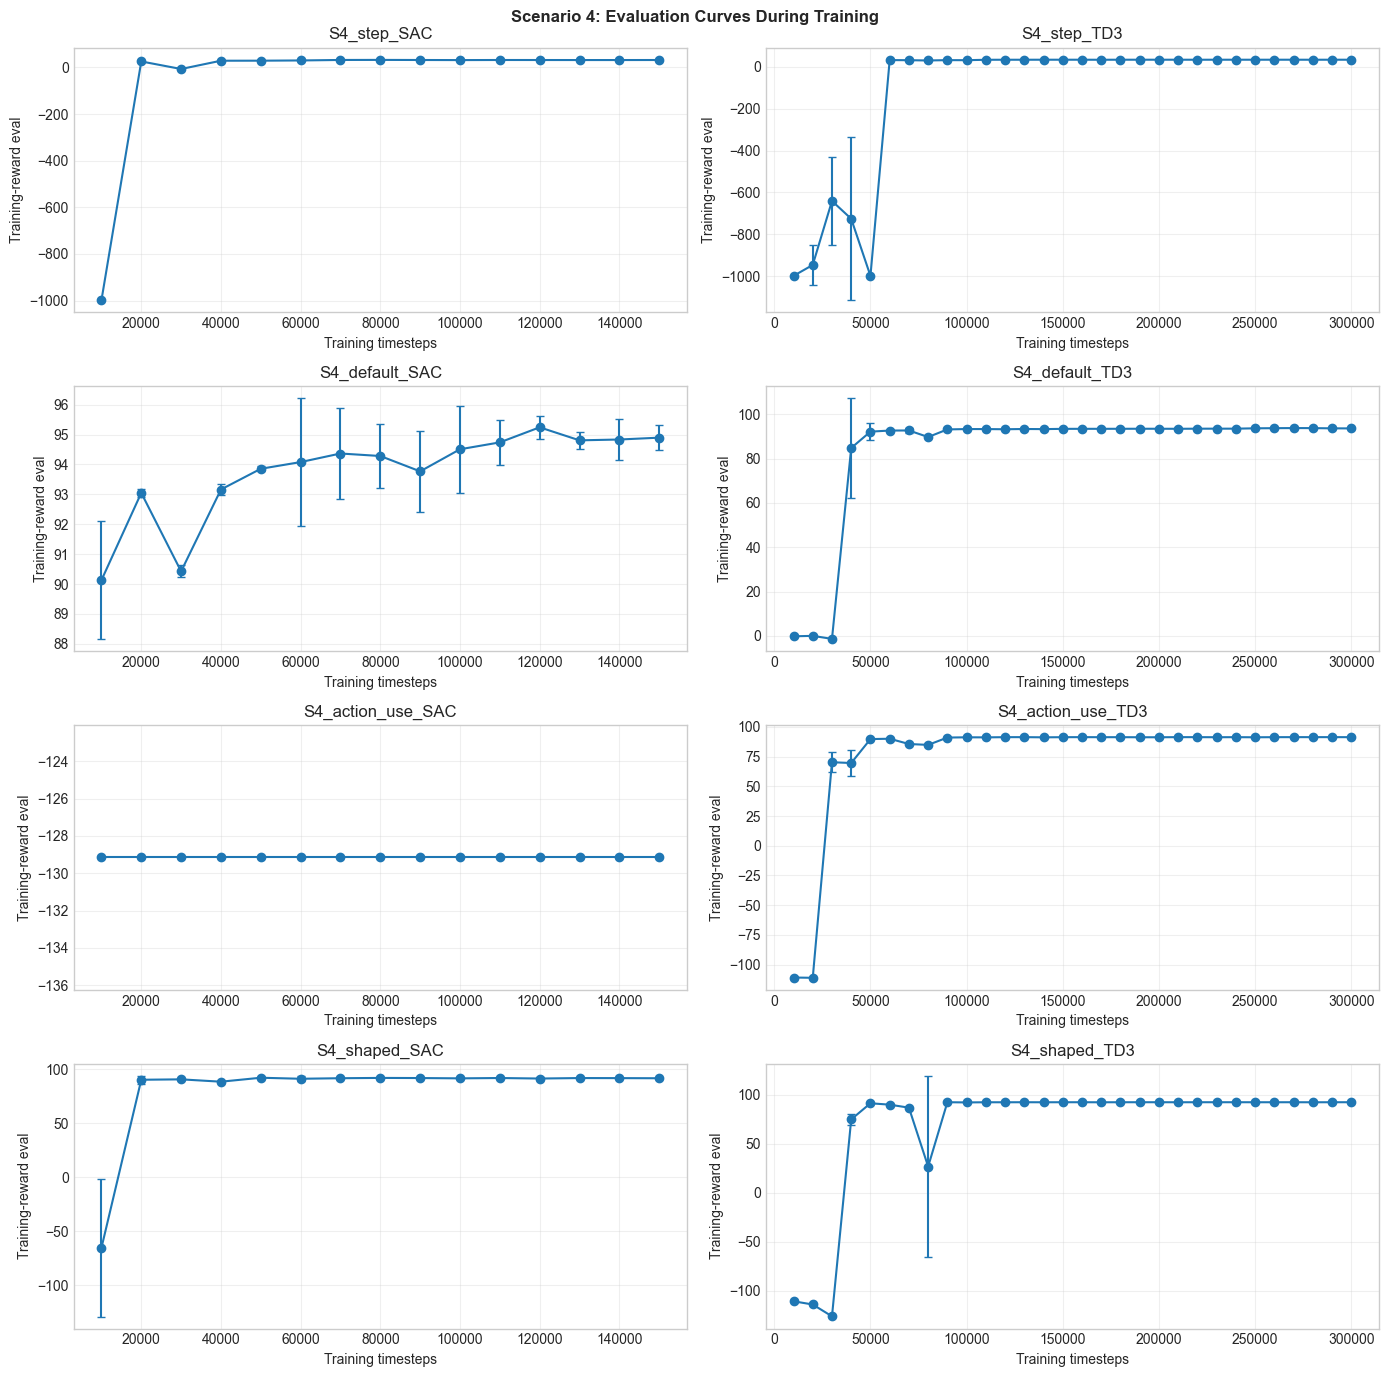

In [6]:
# TensorBoard: run `tensorboard --logdir runs` for full SB3 diagnostics.
# These inline curves show the periodic deterministic evaluation trace collected during training.
n_cols = 2
n_rows = int(np.ceil(len(s4_run_configs) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows), sharex=False)
axes = np.asarray(axes).reshape(-1)
for ax, cfg in zip(axes, s4_run_configs):
    data = s4_results[cfg["run_name"]]
    ax.errorbar(
        data["eval_timesteps"],
        data["eval_mean_rewards"],
        yerr=data["eval_std_rewards"],
        fmt="o-",
        capsize=3,
    )
    ax.set_title(cfg["run_name"])
    ax.set_xlabel("Training timesteps")
    ax.set_ylabel("Training-reward eval")
    ax.grid(True, alpha=0.3)
for ax in axes[len(s4_run_configs):]:
    ax.axis("off")
plt.suptitle("Scenario 4: Evaluation Curves During Training", fontweight="bold")
plt.tight_layout()
plt.show()


**Training Curve Interpretation**

These curves show periodic evaluation during training using each model's training reward. Because the reward definitions differ, the y-values should not be compared directly across all panels. Instead, the useful information is whether each curve escapes the failed region and stabilizes.

The successful TD3 curves show a sharp transition from failed episodes to high reward once the agent discovers the momentum-building trajectory. The successful SAC curves also improve, but their behavior depends more strongly on the reward design. The pure action-use SAC curve remains flat at a poor value, confirming that it never discovers a successful policy under that reward.


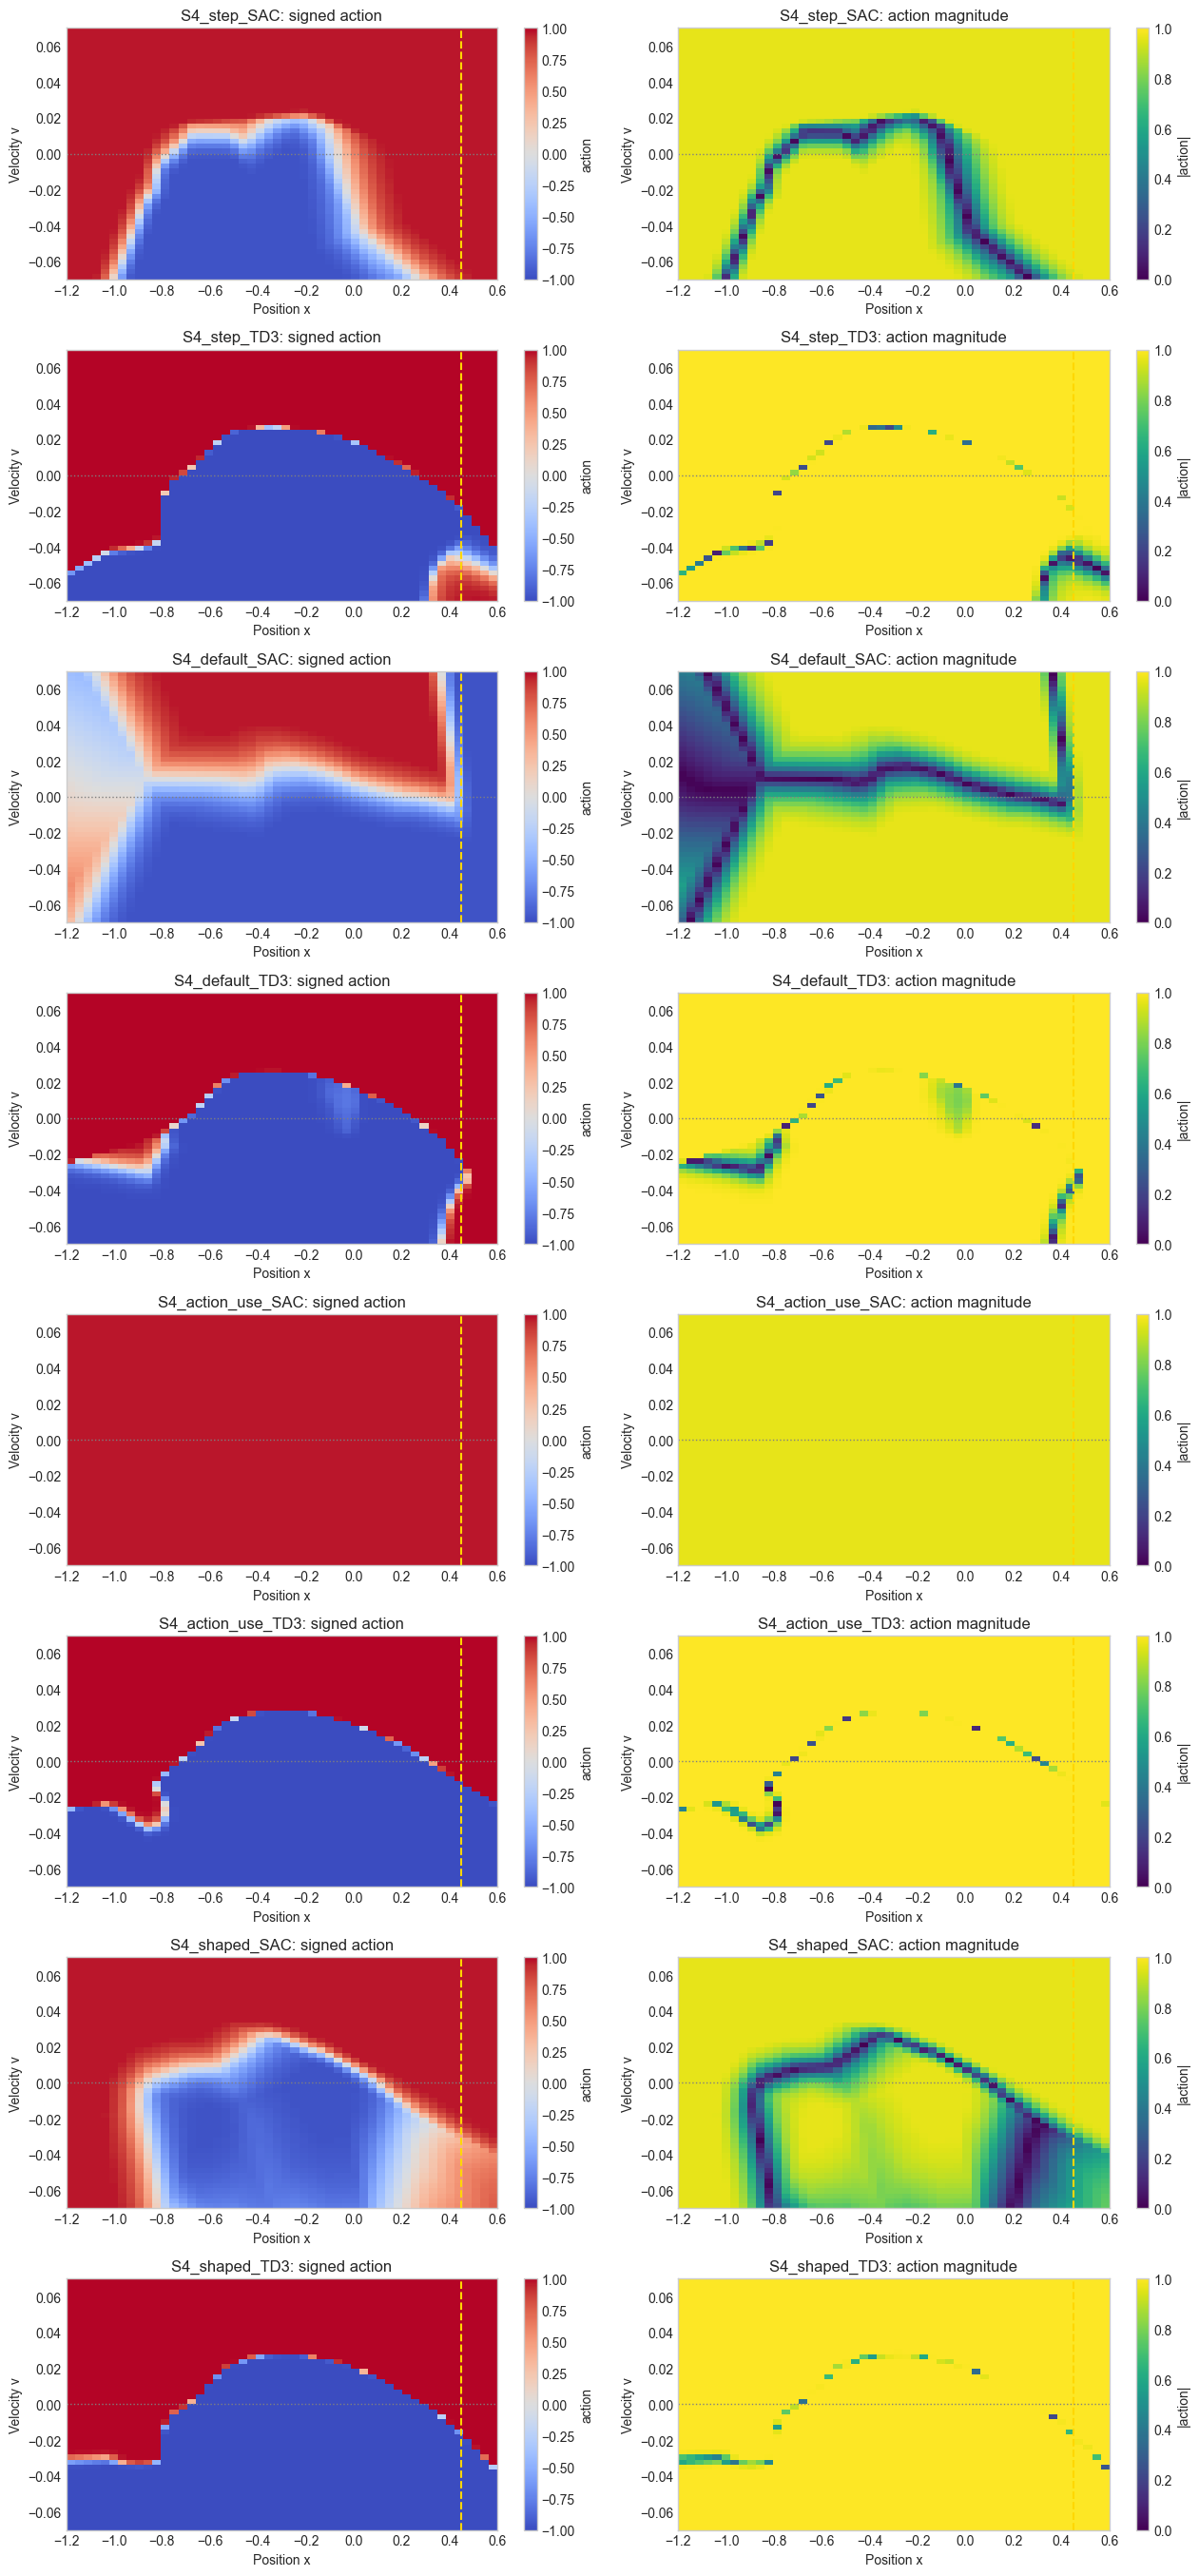

In [7]:
# Continuous policy maps: signed force and force magnitude across the state space.
s4_action_grids = {}
fig, axes = plt.subplots(len(s4_run_configs), 2, figsize=(13, 3.4 * len(s4_run_configs)))
axes = np.asarray(axes)
for row, cfg in enumerate(s4_run_configs):
    run_name = cfg["run_name"]
    grid = mc.get_continuous_policy_grid(s4_results[run_name]["model"], n_bins=50)
    s4_action_grids[run_name] = grid
    mc.plot_continuous_action_heatmap(
        grid, n_bins=50, title=f"{run_name}: signed action", ax=axes[row, 0], magnitude=False
    )
    mc.plot_continuous_action_heatmap(
        grid, n_bins=50, title=f"{run_name}: action magnitude", ax=axes[row, 1], magnitude=True
    )
plt.tight_layout()
plt.show()


**Policy Heatmap Interpretation**

The signed-action maps show which direction the agent pushes in each position-velocity state. The magnitude maps show how strongly the engine is used. A physically sensible Mountain Car policy should usually push in the direction that reinforces current momentum: push left while moving left to climb the left hill, then push right while moving right to climb toward the goal.

The successful TD3 policies show a clear bang-bang structure with actions close to `-1` or `+1` over most of the state space. This explains why TD3 reaches the goal quickly, but also why its fuel usage is high. The successful SAC variants show more variation and, in some regions, lower action magnitudes. This can reduce squared fuel cost, but it also tends to increase steps and non-null action count.

`S4_action_use_SAC` is the failure case in these maps: it selects almost the same high positive action everywhere. That policy is not state-dependent enough to build the required left-right oscillation, so it uses the engine heavily without reaching the goal.


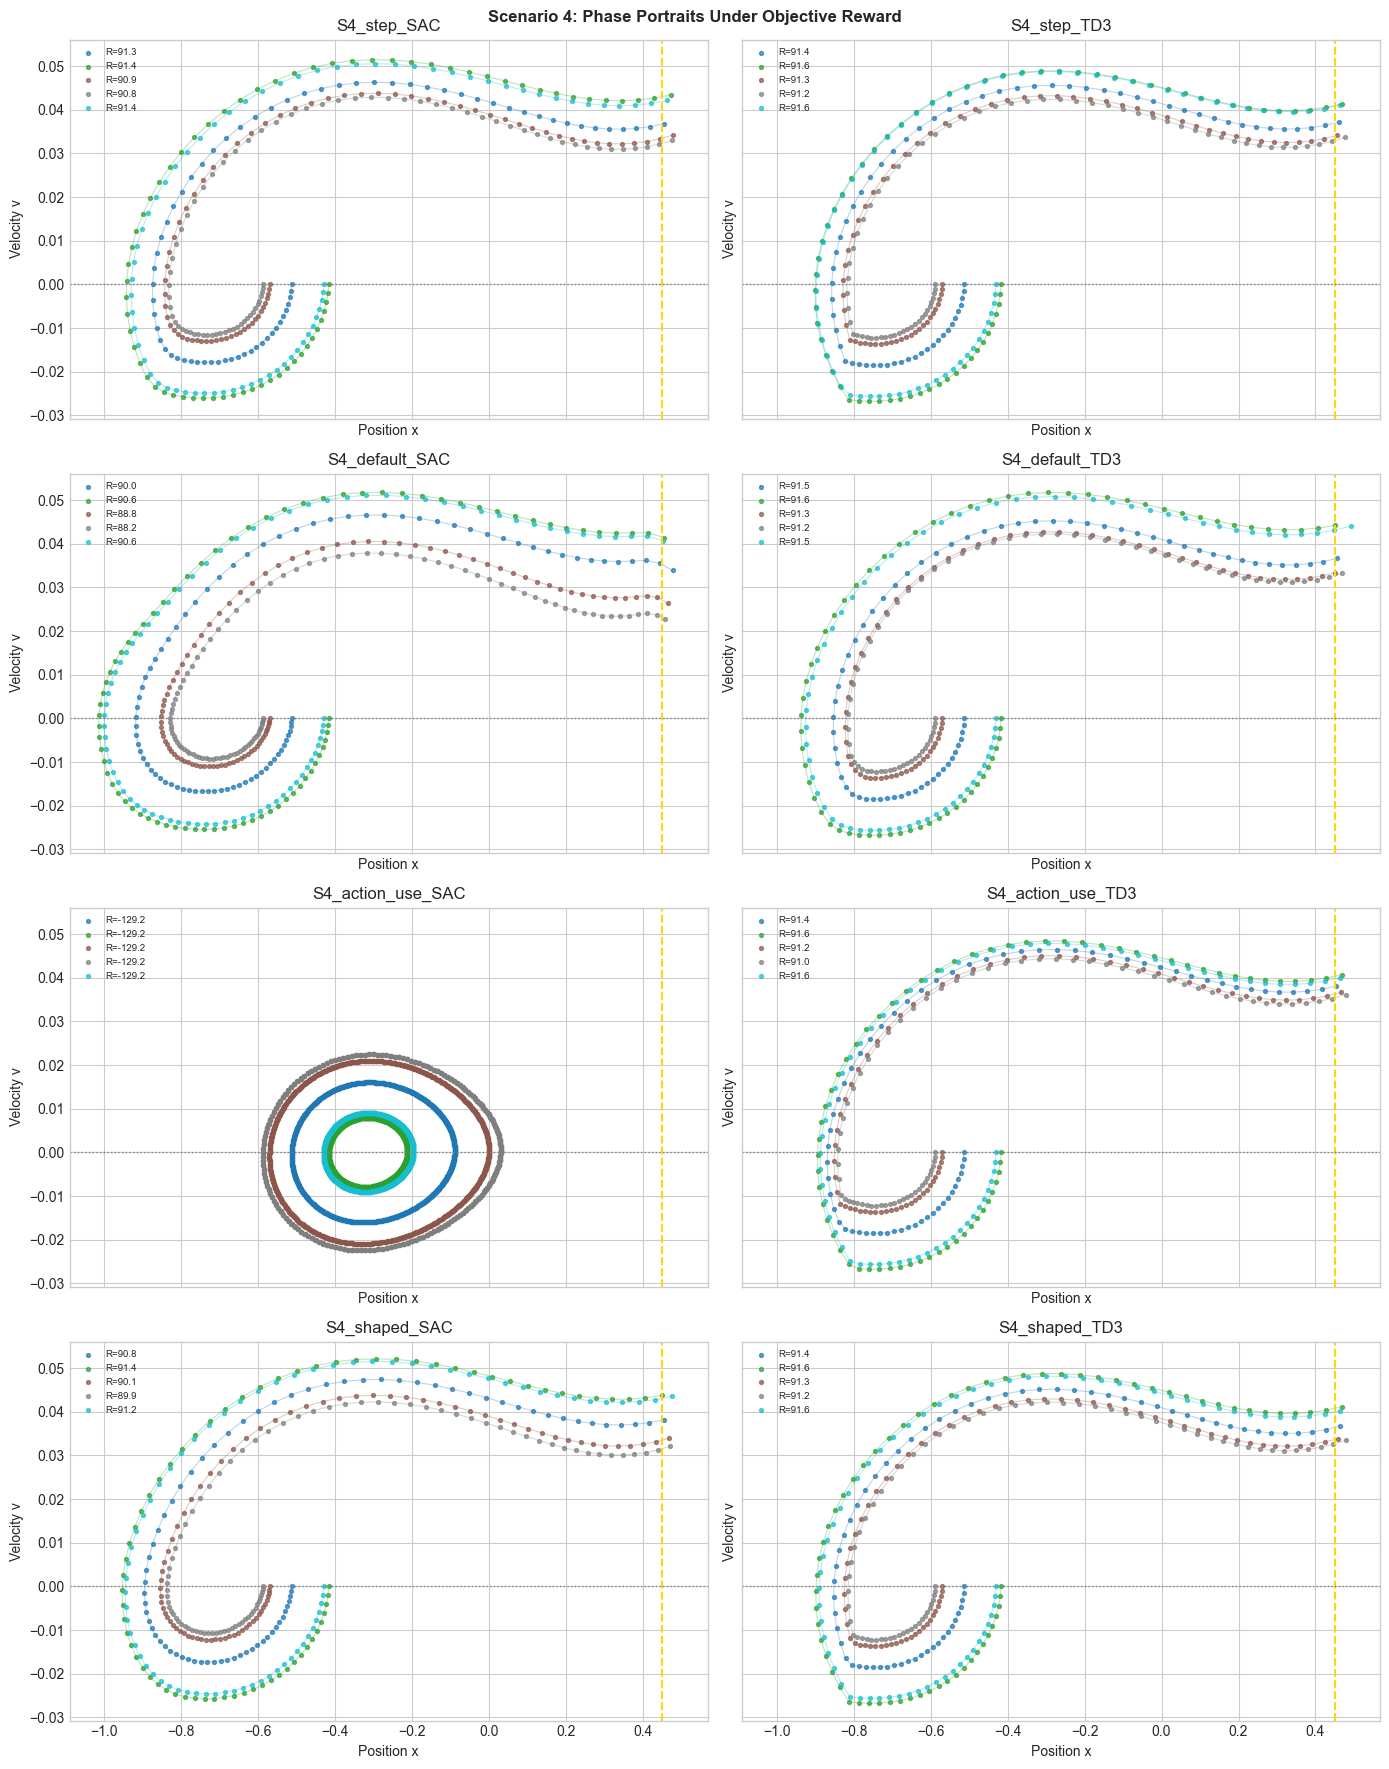

In [8]:
# Phase portraits show whether each policy learns the left-right oscillation needed for momentum.
n_cols = 2
n_rows = int(np.ceil(len(s4_run_configs) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)
for ax, cfg in zip(axes, s4_run_configs):
    run_name = cfg["run_name"]
    trajectories, rewards = mc.collect_trajectories(
        S4_OBJECTIVE_EVAL_ENV_FACTORY,
        s4_agent_fn(s4_results[run_name]["model"]),
        n_episodes=5,
        max_steps=mc.S4_MAX_STEPS,
    )
    mc.plot_phase_portrait(
        trajectories, rewards, title=run_name, ax=ax, goal_position=0.45
    )
for ax in axes[len(s4_run_configs):]:
    ax.axis("off")
plt.suptitle("Scenario 4: Phase Portraits Under Objective Reward", fontweight="bold")
plt.tight_layout()
plt.show()


**Phase Portrait and Physical Interpretation**

The phase portraits show trajectories in position-velocity space. Successful policies produce the characteristic Mountain Car loop: the car first moves left, gains potential energy, then reverses and climbs the right hill with enough velocity to cross the goal line.

The TD3 trajectories are compact and consistent, which matches the numerical result: they solve the task quickly and reliably. The successful SAC trajectories show the same physical structure but are generally wider or slower, especially for the default and shaped variants. This reflects a more cautious or less saturated use of action.

`S4_action_use_SAC` does not form the goal-reaching loop. Its trajectories remain trapped around the valley, showing that simply applying a large force is not enough. The agent must switch direction at the right points in the state space to exploit the hill physics.


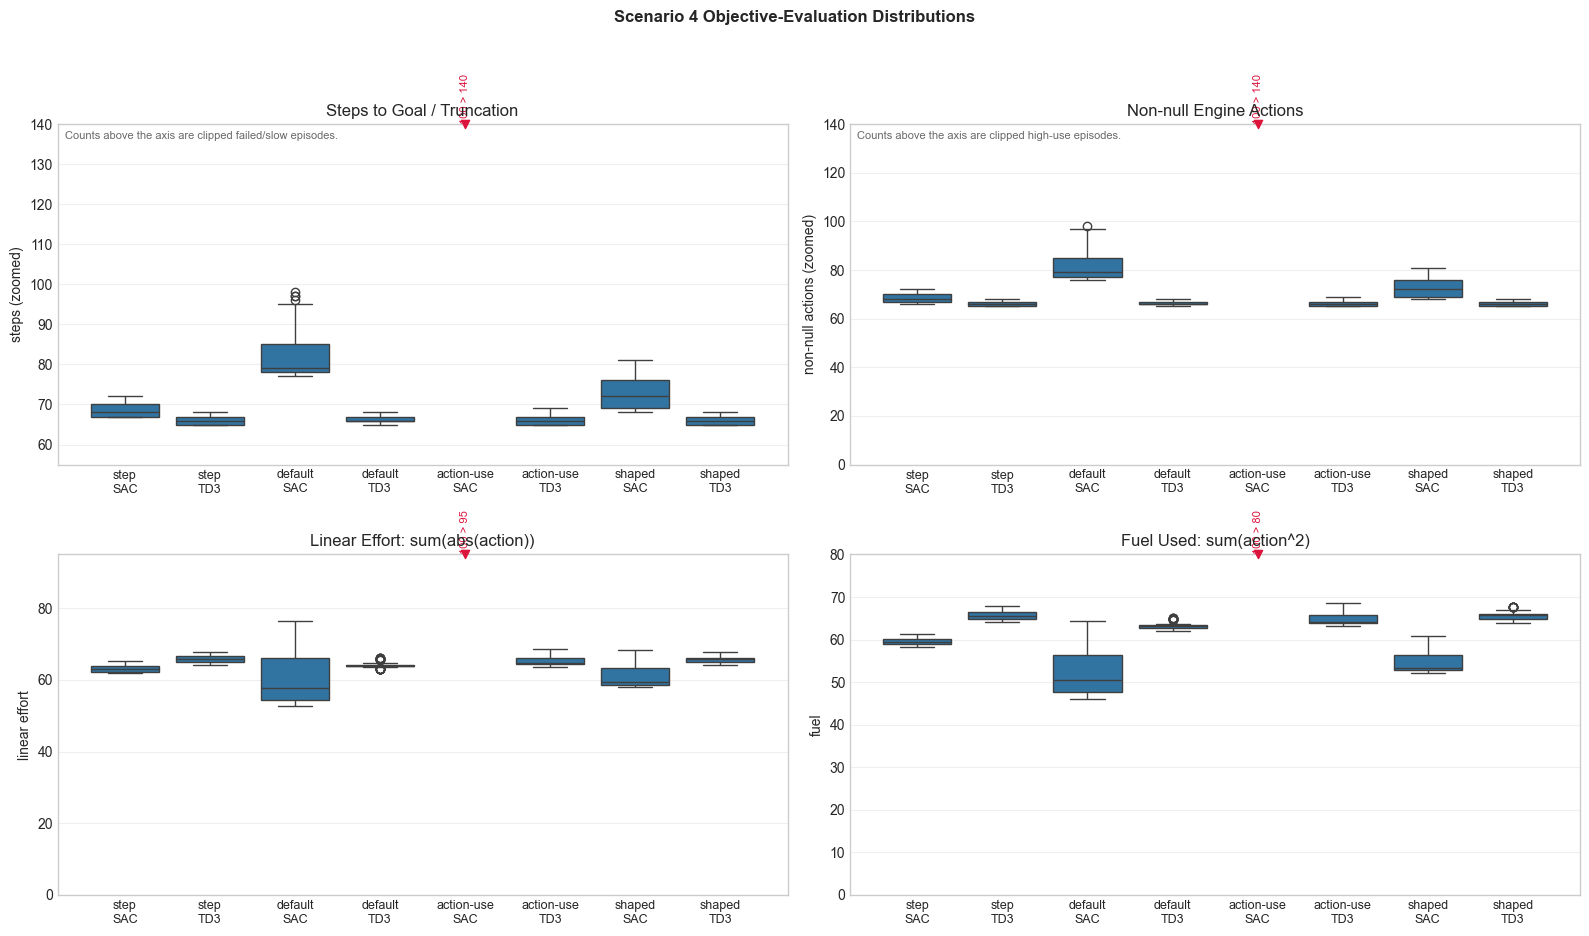

In [9]:
# Distribution checks: high variability means an agent is unreliable even when the mean looks good.
s4_episode_rows = []
for cfg in s4_run_configs:
    run_name = cfg["run_name"]
    for ep in s4_results[run_name]["objective_eval"]["episodes"]:
        s4_episode_rows.append({**ep, "run": run_name, "algorithm": cfg["algorithm"], "reward_design": cfg["reward_design"]})

s4_episode_df = pd.DataFrame(s4_episode_rows)

run_order = [cfg["run_name"] for cfg in s4_run_configs]

def s4_short_label(run_name):
    reward_name, algorithm = run_name.replace("S4_", "").rsplit("_", 1)
    reward_name = reward_name.replace("action_use", "action-use")
    return f"{reward_name}\n{algorithm}"

label_order = [s4_short_label(run_name) for run_name in run_order]
label_map = dict(zip(run_order, label_order))
s4_episode_df["run_label"] = pd.Categorical(
    s4_episode_df["run"].map(label_map), categories=label_order, ordered=True
)

fig, axes = plt.subplots(2, 2, figsize=(16, 9.5))
plot_specs = [
    {
        "metric": "steps",
        "title": "Steps to Goal / Truncation",
        "ylabel": "steps (zoomed)",
        "ylim": (55, 140),
        "note": "Counts above the axis are clipped failed/slow episodes.",
    },
    {
        "metric": "non_null_actions",
        "title": "Non-null Engine Actions",
        "ylabel": "non-null actions (zoomed)",
        "ylim": (0, 140),
        "note": "Counts above the axis are clipped high-use episodes.",
    },
    {
        "metric": "linear_effort",
        "title": "Linear Effort: sum(abs(action))",
        "ylabel": "linear effort",
        "ylim": (0, 95),
        "note": None,
    },
    {
        "metric": "fuel",
        "title": "Fuel Used: sum(action^2)",
        "ylabel": "fuel",
        "ylim": (0, 80),
        "note": None,
    },
]

for ax, spec in zip(axes.flat, plot_specs):
    metric = spec["metric"]
    y_low, y_high = spec["ylim"]
    sns.boxplot(
        data=s4_episode_df,
        x="run_label",
        y=metric,
        order=label_order,
        ax=ax,
        showfliers=True,
    )
    ax.set_ylim(y_low, y_high)
    ax.set_title(spec["title"])
    ax.set_xlabel("")
    ax.set_ylabel(spec["ylabel"])
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.grid(True, axis="y", alpha=0.3)

    clipped_counts = (
        s4_episode_df.groupby("run_label", observed=False)[metric]
        .apply(lambda values: int((values > y_high).sum()))
        .reindex(label_order, fill_value=0)
    )
    for x_pos, clipped in enumerate(clipped_counts):
        if clipped:
            ax.scatter(x_pos, y_high, marker="v", color="crimson", s=35, clip_on=False, zorder=5)
            ax.text(
                x_pos,
                y_high,
                f"{clipped} > {y_high:g}",
                color="crimson",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
                clip_on=False,
            )

    if spec["note"]:
        ax.text(
            0.01,
            0.98,
            spec["note"],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            color="dimgray",
        )

plt.suptitle("Scenario 4 Objective-Evaluation Distributions", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


**Distribution Plot Interpretation**

The boxplots show reliability across the `100` evaluation episodes. The axes for steps and non-null actions are zoomed so that successful policies are readable; red clipped markers indicate values above the visible range, mainly failed or very high-use episodes.

The TD3 distributions are narrow around roughly `66` steps and `66` non-null actions, so the TD3 result is both fast and consistent. The SAC distributions show more variation. `S4_default_SAC` uses less squared fuel but takes more steps, while `S4_shaped_SAC` is closer to the TD3 behavior but still slower.

This figure highlights the trade-off within Scenario 4: lower fuel is not automatically better if it costs more non-null actions or more time. Under the Scenario 4 objective, the reliable fast TD3 policies score best even though they use high-magnitude actions.


In [10]:
# Explanation bridge: discretize continuous actions into left / idle / right and fit the same regression explainer.
def discretize_continuous_action_grid(action_grid, threshold=0.05):
    return np.where(action_grid < -threshold, 0, np.where(action_grid > threshold, 2, 1))

s4_explanations = {}
for run_name, grid in s4_action_grids.items():
    discrete_policy = discretize_continuous_action_grid(grid, threshold=0.05)
    acc, weights, feature_names = mc.explain_policy_regression(
        discrete_policy, n_bins=grid.shape[0], scenario_name=run_name
    )
    s4_explanations[run_name] = {
        "accuracy": acc,
        "weights": weights,
        "feature_names": feature_names,
    }


Policy Explanation: S4_step_SAC
Logistic Regression Accuracy: 81.4%
Feature importance (mean |coef| across classes):
 sin(3*pos)  : 0.7670
 vel         : 0.7145
 pos^2       : 0.4127
 pos*vel     : 0.3601
 vel^2       : 0.1460
 |vel|       : 0.0801
 pos         : 0.0114

Policy Explanation: S4_step_TD3
Logistic Regression Accuracy: 92.3%
Feature importance (mean |coef| across classes):
 vel         : 1.1412
 pos^2       : 0.7079
 sin(3*pos)  : 0.5503
 pos*vel     : 0.4734
 |vel|       : 0.1465
 vel^2       : 0.1302
 pos         : 0.1248

Policy Explanation: S4_default_SAC
Logistic Regression Accuracy: 78.6%
Feature importance (mean |coef| across classes):
 vel         : 0.8737
 pos         : 0.2724
 pos*vel     : 0.1794
 pos^2       : 0.1547
 |vel|       : 0.1408
 vel^2       : 0.1130
 sin(3*pos)  : 0.0642

Policy Explanation: S4_default_TD3
Logistic Regression Accuracy: 94.3%
Feature importance (mean |coef| across classes):
 vel         : 1.1961
 pos*vel     : 0.7060
 pos^2       : 0

**Policy Explanation and Final Scenario 4 Conclusion**

The logistic-regression explainer converts each continuous policy map into left, idle, and right action regions, then checks whether a simple model using physical features can approximate the learned policy. High accuracy means the policy has a relatively simple decision boundary in the engineered state features.

The successful TD3 policies have high explanation accuracy, above `92%`, and velocity is consistently the most important feature. This is physically sensible: Mountain Car depends heavily on momentum, so the sign and size of velocity should strongly influence whether the agent pushes left or right. Features such as `sin(3*pos)`, `pos^2`, and `pos*vel` also matter because they encode hill geometry and momentum-position interaction.

The successful SAC variants are also explainable, though generally less cleanly than TD3. `S4_action_use_SAC` has zero feature importance because its policy is effectively constant after discretization. That confirms the visual diagnosis from the heatmaps and phase portrait.

Overall, Scenario 4 shows that TD3 with appropriate exploration is the most reliable method tested here. SAC can solve the task when trained with the step, default, or shaped reward, but the pure action-use reward remains difficult for SAC. The final interpretation is that the scenario-aligned reward is not automatically the easiest training signal: successful learning still depends on whether the algorithm can discover the momentum-building trajectory before the action-use penalty drives it into a poor local policy.


## 6. Comparative Analysis

## 7. Explanation Tools